In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/shenzhewen/Desktop/Walmart_Sales.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Feature Engineering

In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

Extract calendar-based features for later analysis/modeling：year/month/week help capture seasonality patterns

In [4]:
df['holiday'] = df['Holiday_Flag'].map({1:1,0:0})

In [9]:
weekly_total = (
    df.groupby("Date")
    .agg(
        total_weekly_sales=("Weekly_Sales","sum"),
        holiday_share=("Holiday_Flag","mean"),
        avg_temp=("Temperature","mean"),
        avg_fuel_price=("Fuel_Price","mean"),
        avg_cpi=("CPI","mean"),
        avg_unemployment=("Unemployment","mean")
    )
    .sort_index()
)

Aggregate store-level weekly sales to build the enterprise-level forecasting series

Also aggregate exogenous variables for later ARIMAX / regression models

In [11]:
weekly_total.head()

,total_weekly_sales,holiday_share,avg_temp,avg_fuel_price,avg_cpi,avg_unemployment
Date,,,,,,
2010-02-05,49750740.50,0.0,34.037333,2.717844,167.730885,8.619311
2010-02-12,48336677.63,1.0,34.151333,2.694022,167.825608,8.619311
2010-02-19,48276993.78,0.0,37.719778,2.672067,167.871686,8.619311
2010-02-26,43968571.13,0.0,39.243556,2.683933,167.909657,8.619311
2010-03-05,46871470.30,0.0,42.917333,2.731200,167.947628,8.619311


## 3 Representative Store

In [5]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values()

store_sales.head()

Store
33    259861.692028
44    302748.866014
5     318011.810490
36    373511.992797
38    385731.653287
Name: Weekly_Sales, dtype: float64

In [6]:
low_store = store_sales.idxmin()

high_store = store_sales.idxmax()

median_sales = store_sales.median()

mid_store = (store_sales - median_sales).abs().idxmin()

print("Low volume store:", low_store)
print("Middle volume store:", mid_store)
print("High volume store:", high_store)

Low volume store: 33
Middle volume store: 34
High volume store: 20


In [7]:
selected_stores = [low_store, mid_store, high_store]

df_selected = df[df["Store"].isin(selected_stores)]

df_selected.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,holiday
2717,20,2010-02-05,2401395.47,0,25.92,2.784,204.247194,8.187,2010,2,5,0
2718,20,2010-02-12,2109107.90,1,22.12,2.773,204.385747,8.187,2010,2,6,1
2719,20,2010-02-19,2161549.76,0,25.43,2.745,204.432100,8.187,2010,2,7,0
2720,20,2010-02-26,1898193.95,0,32.32,2.754,204.463087,8.187,2010,2,8,0
2721,20,2010-03-05,2119213.72,0,31.75,2.777,204.494073,8.187,2010,3,9,0


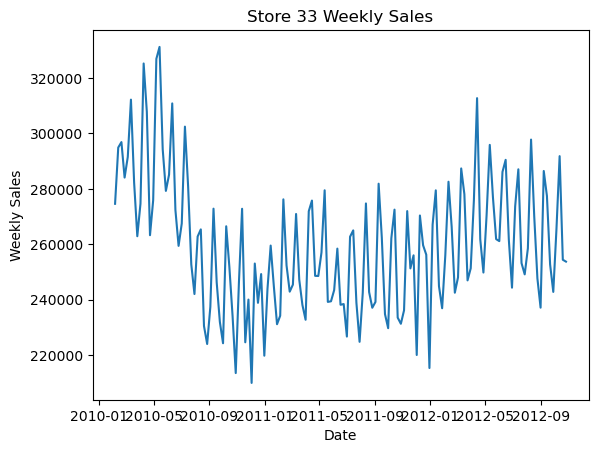

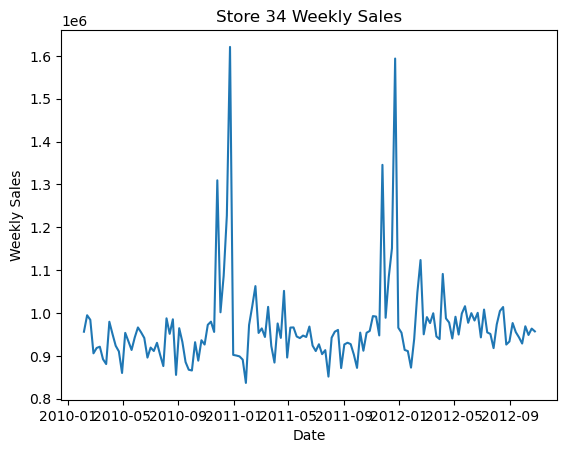

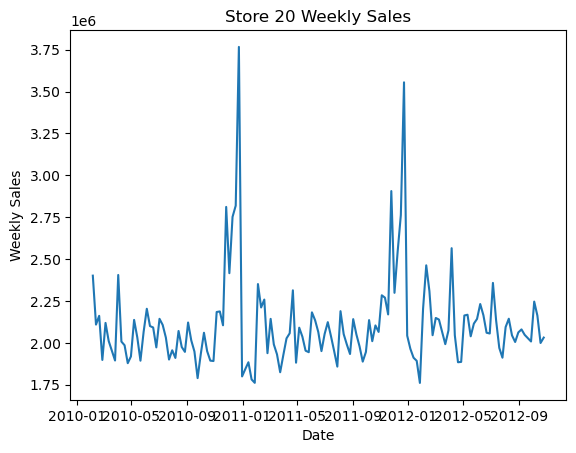

In [8]:
import matplotlib.pyplot as plt

for store in selected_stores:
    
    temp = df[df["Store"] == store]
    
    plt.figure()
    plt.plot(temp["Date"], temp["Weekly_Sales"])
    plt.title(f"Store {store} Weekly Sales")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.show()

Stores were categorized based on their average weekly sales.
One representative store was selected from high-, middle-, and low-volume groups to ensure the forecasting models were evaluated across different demand levels.

In [12]:
weekly_total.reset_index().to_csv(
    "walmart_total_weekly.csv",
    index=False
)

In [13]:
df_selected.to_csv(
    "walmart_three_stores.csv",
    index=False
)